# Black-box DFL on a small QP

A network predicts the returns of 12 assets from 6 market features. A mean-variance optimizer turns the prediction into a
portfolio, and the black box returns its regret (0 = best portfolio, 1 = worst). The policy adds Gaussian noise to its
prediction, pays one call per step, and trains with a score-function gradient.

This notebook reproduces the paper's QP figure (`fig_qp_adam`): Adam, 12,800 calls, 10 seeds. Q and Q + Δ* use a reward
model f-hat (one quadratic per day) that starts from an offline dataset of 50 calls per day.

Runs are saved to `_qp_adam_runs_offline/` as one `.npy` file per method and seed. Finished runs are skipped, so the
notebook resumes after a crash and only plots when everything is there. A full run takes about 20 minutes on 40 CPU cores.

In [1]:
import os; os.environ["CUDA_VISIBLE_DEVICES"] = ""
import sys, time, numpy as np, torch, torch.nn as nn, matplotlib.pyplot as plt
from multiprocessing import get_context
torch.set_num_threads(1)                    # the models are tiny: more threads only slow the loops down
sys.path.insert(0, "..")
from qp_continuous import ContinuousQP
from qp_rowwise import RowAccount
from baselines import group_weights, lax_weights, Surrogate

SEEDS   = range(10)                         # the paper uses 10
CALLS   = 12800                             # paid calls per run
N_OFF   = 50                                # offline calls per day for the reward model
N_PROCS = 40
OUT     = "_qp_adam_runs_offline"
os.makedirs(OUT, exist_ok=True)

## The problem

In [2]:
d, p, n_days = 12, 6, 6            # assets, market features, training days
lam, sigma   = 1.3, 0.15           # the optimizer's risk aversion, the size of the policy's noise

rng = np.random.default_rng(0)
X = rng.standard_normal((n_days, p))                                                  # features, one row per day
true_returns = 1 / (1 + np.exp(-2 * X @ rng.standard_normal((d, p)).T / np.sqrt(p)))   # hidden: what the model must learn
F = rng.standard_normal((d, d // 2)) / np.sqrt(d // 2)
Sigma = F @ F.T + 0.25 * np.eye(d)                                                    # hidden: how the assets co-move

Sinv = np.linalg.inv(Sigma); u = Sinv @ np.ones(d)
M, b0 = (Sinv - np.outer(u, u) / u.sum()) / lam, u / u.sum()      # optimizer: portfolio(c) = M c + b0

def value(day, z):                                                # what a portfolio is really worth that day
    return true_returns[day] @ z - lam / 2 * z @ Sigma @ z
best  = [value(i,  M @ true_returns[i] + b0) for i in range(n_days)]
worst = [value(i, -M @ true_returns[i] + b0) for i in range(n_days)]

def black_box(day, predicted_returns):                            # regret: 0 = best possible, 1 = worst
    return (best[day] - value(day, M @ predicted_returns + b0)) / (best[day] - worst[day])

box = ContinuousQP.from_data(X, true_returns, Sigma, lam=lam, sigma=sigma)   # used for the exact regret on the plot and the exact-gradient reference

In [3]:
class Model(nn.Module):                                           # one network shared by all assets, plus a fixed code per asset
    def __init__(self, h=8, pos_scale=0.1, seed=0):
        super().__init__(); torch.manual_seed(seed)
        self.trunk, self.head = nn.Linear(p, h), nn.Linear(h, 1)
        self.register_buffer("pos", torch.randn(d, h) * pos_scale)
        nn.init.zeros_(self.head.weight); nn.init.zeros_(self.head.bias)    # start by predicting 0 for every asset

    def forward(self, x):                                                   # features (..., p) -> returns (..., d)
        return self.head(torch.tanh(self.trunk(x).unsqueeze(-2) + self.pos)).squeeze(-1)

shared = lambda seed: Model(seed=seed)

## Baselines

REINFORCE has no baseline. RLOO, GRPO and OTB draw 8 samples per step and use the group as the baseline. LAX fits a
surrogate per day on that day's last 128 samples, starting from the offline dataset. The exact gradient is the reference.

In [4]:
Xt = torch.as_tensor(X, dtype=torch.float32)
surrogates = {}

def nudge(model, day, seed, n):                                          # n noisy predictions and their scores
    J, mu = (x.float() for x in box.jac(model, day))                      # J[j] = d mu_j / d theta
    b = mu + sigma * torch.randn(n, d, generator=torch.Generator().manual_seed(seed))
    return J, mu, b, torch.tensor([black_box(day, x.numpy()) for x in b], dtype=torch.float32)

def reinforce(model, day, seed):
    J, mu, b, f = nudge(model, day, seed, 1)
    return (f[:, None] * (b - mu) / sigma ** 2).mean(0) @ J

def grouped(method, K=8):                                                 # RLOO, GRPO, OTB: K samples per step
    def gradient(model, day, seed):
        J, mu, b, f = nudge(model, day, seed, K)
        return group_weights(method, f, (b - mu) / sigma ** 2, torch.arange(d).expand(K, d), (J * J).sum(1)) @ J
    return gradient

exact = lambda model, day, seed: box.true_grad(model, day)

def train(make_model, gradient, calls=CALLS, lr=0.01, seed=0, every=100, K=1):   # Adam; K calls to the black box per step
    model = make_model(seed); opt = torch.optim.Adam(model.parameters(), lr=lr); surrogates.clear(); log = []
    for step in range(0, calls + 1, K):
        if len(log) <= step // every:
            log.append(box.regret(model))                                 # exact regret, for the plot only
        if step == calls:
            break
        g = gradient(model, (step // K) % n_days, seed * 100000 + step)
        opt.zero_grad(); k = 0
        for prm in model.parameters():
            prm.grad = g[k:k + prm.numel()].view_as(prm).float(); k += prm.numel()
        opt.step()
    return log

## The offline dataset and the reward model

50 samples per day from the initial policy, scored once. Each day's f-hat is a quadratic in the prediction, fitted by
least squares to the offline calls and to every call paid on that day so far. It grows from a constant to linear to the
full quadratic as calls come in, with the ridge picked by leave-one-out cross-validation.

In [5]:
gen = torch.Generator().manual_seed(2026)
OFF = {i: sigma * torch.randn(N_OFF, d, generator=gen) for i in range(n_days)}                                   # b ~ the initial policy
OFF_F = {i: torch.tensor([black_box(i, b.numpy()) for b in OFF[i]], dtype=torch.float32) for i in range(n_days)}  # scored once
print(f"offline dataset: {N_OFF} calls per day, mean regret {np.mean([OFF_F[i].mean() for i in range(n_days)]):.3f}")

from types import SimpleNamespace
IU = torch.triu_indices(d, d)
def feats(b):                                                              # 1, b, and every b_j b_k
    return torch.cat([torch.ones(*b.shape[:-1], 1, dtype=b.dtype), b, (b[..., :, None] * b[..., None, :])[..., IU[0], IU[1]]], -1)

class RewardModel:                                                         # f-hat: one quadratic per day
    RIDGES = (1e-3, 1e-2, 1e-1, 1.0)
    def __init__(self):
        self.B, self.F, self.coef = {i: [] for i in range(n_days)}, {i: [] for i in range(n_days)}, {}
        for i in range(n_days):                                            # start from the offline dataset
            for b, f in zip(OFF[i], OFF_F[i]): self.add(i, b, f)
    def add(self, day, b, f): self.B[day].append(b.double()); self.F[day].append(float(f)); self.coef.pop(day, None)
    def fit(self, day):
        if day in self.coef: return self.coef[day]
        P = 1 + d + d * (d + 1) // 2; th = torch.zeros(P, dtype=torch.float64); F = torch.tensor(self.F[day], dtype=torch.float64)
        if len(F) == 0:
            seen = [f for i in range(n_days) for f in self.F[i]]; th[0] = np.mean(seen) if seen else 0.0
        else:
            order = P if len(F) >= P else 1 + d if len(F) >= 1 + d else 1  # mean, linear, quadratic, each once determined
            Phi = feats(torch.stack(self.B[day]))[:, :order]; G, rhs = Phi.T @ Phi, Phi.T @ F; best = None
            for ridge in (self.RIDGES if order > 1 else (0.0,)):
                R = ridge * torch.eye(order, dtype=torch.float64); R[0, 0] = 0.0; Ainv = torch.linalg.pinv(G + R)
                th_r = Ainv @ rhs; h = ((Phi @ Ainv) * Phi).sum(1).clamp_max(1 - 1e-9)
                loo = (((F - Phi @ th_r) / (1 - h)) ** 2).mean()               # leave-one-out squared error
                if best is None or loo < best[0]: best = (loo, th_r)
            th[:order] = best[1]
        self.coef[day] = th; return th
    def box(self):                                                         # f-hat in the form the exact maps read
        th = [self.fit(i) for i in range(n_days)]; H = []
        for t in th: Hm = torch.zeros(d, d, dtype=torch.float64); Hm[IU[0], IU[1]] = t[1 + d:]; H.append((Hm + Hm.T) / 2)
        fb = SimpleNamespace(a=[float(t[0]) for t in th], g=[t[1:1 + d] for t in th], H=H, sigma=sigma, d=d, o=SimpleNamespace(X=X, n_train=n_days))
        fb.jac = lambda net, i: ContinuousQP.jac(fb, net, i); fb.f = lambda i, b: fb.a[i] + b @ fb.g[i] + torch.einsum("...j,jk,...k->...", b, fb.H[i], b)
        return fb

offline dataset: 50 calls per day, mean regret 0.367


## Q and Q + Δ*

Q-hat and the row-wise residual Δ*-hat are exact maps of f-hat. The true reward enters only as the paid score of the
sample, so both estimators stay unbiased for any f-hat.

In [6]:
def fitted(kind, rm):                                                      # kind: None (Q), "row" (Q + Δ*)
    def gradient(model, day, seed):
        acc = RowAccount(rm.box(), model, day)
        eps = torch.randn(1, d, generator=torch.Generator().manual_seed(seed), dtype=torch.float64); b = acc.mu[None] + sigma * eps
        f = torch.tensor([black_box(day, b[0].numpy())], dtype=torch.float64)       # the one paid call
        H = acc.cqp.H[day]; fut = torch.cat([H.diagonal().flip(0).cumsum(0).flip(0)[1:], H.new_zeros(1)])
        Q = torch.stack([acc.cqp.f(day, torch.cat([b[:, :j + 1], acc.mu[None, j + 1:]], 1)) + sigma ** 2 * fut[j] for j in range(d)], 1)   # E[f-hat | b_<=j]
        coef = (f[:, None] - Q) * eps / sigma + torch.as_tensor(acc.G)[None] + 2 * (b - acc.mu[None]) @ torch.tril(H, -1).T
        g = (coef @ acc.J).numpy()
        if kind and acc.hermite("prefix"): g = g - acc.hermite_values(eps.numpy()) @ acc.projected(kind)      # Δ*-hat, built before this call is added
        rm.add(day, b[0], f[0]); return torch.as_tensor(g[0])
    return gradient

def lax(window=128, steps=8):                                              # LAX, its surrogate and replay buffer started from the offline dataset
    replay = {}
    def gradient(model, day, seed):
        J, mu, b, f = nudge(model, day, seed, 1)
        if day not in surrogates:
            surrogates[day] = Surrogate(d); replay[day] = (list(OFF[day]), list(OFF_F[day]))
            B, F = (torch.stack(v[-window:]) for v in replay[day])
            for _ in range(steps): surrogates[day].fit(lax_weights(surrogates[day], mu, B, F, sigma), J @ J.T)
        c = surrogates[day]; g = lax_weights(c, mu, b, f, sigma).detach() @ J
        replay[day][0].append(b[0]); replay[day][1].append(f[0]); B, F = (torch.stack(v[-window:]) for v in replay[day])
        for _ in range(steps): c.fit(lax_weights(c, mu, B, F, sigma), J @ J.T)
        return g
    return gradient

## Run

In [7]:
#            name in the figure: (file name, gradient maker, calls per step, Adam lr)
METHODS = {"REINFORCE":      ("exact_REINFORCE",          lambda: reinforce,          1, 0.005),
           "RLOO":           ("exact_RLOO",               lambda: grouped("RLOO"),    8, 0.01),
           "GRPO":           ("exact_GRPO",               lambda: grouped("GRPO"),    8, 0.01),
           "OTB":            ("exact_OTB",                lambda: grouped("OTB"),     8, 0.01),
           "LAX":            ("exact_LAX",                lambda: lax(),              1, 0.005),
           "Q":              ("fitted_pQ",                lambda: fitted(None, RewardModel()),  1, 0.005),
           "Q + Δ*":         ("fitted_pQprow-wiseΔ",      lambda: fitted("row", RewardModel()), 1, 0.005),
           "exact gradient": ("exact_exactgradient",      lambda: exact,              1, 0.005)}
path = lambda name, seed: os.path.join(OUT, f"{METHODS[name][0]}_s{seed}.npy")

def job(args):
    name, seed = args; _, make, K, lr = METHODS[name]; t0 = time.time()
    log = np.array(train(shared, make(), lr=lr, seed=seed, K=K)); np.save(path(name, seed), log)
    return name, seed, log, time.time() - t0

todo = [(n, s) for n in METHODS for s in SEEDS if not os.path.exists(path(n, s))]
print(f"{len(todo)} runs to do")
if todo:
    with get_context("fork").Pool(min(N_PROCS, len(todo))) as pool:
        for name, seed, log, dt in pool.imap_unordered(job, todo):
            print(f"{name:15s} seed {seed}: regret {log[0]:.3f} -> {log[-1]:.3f}  ({dt:.0f}s)", flush=True)

0 runs to do


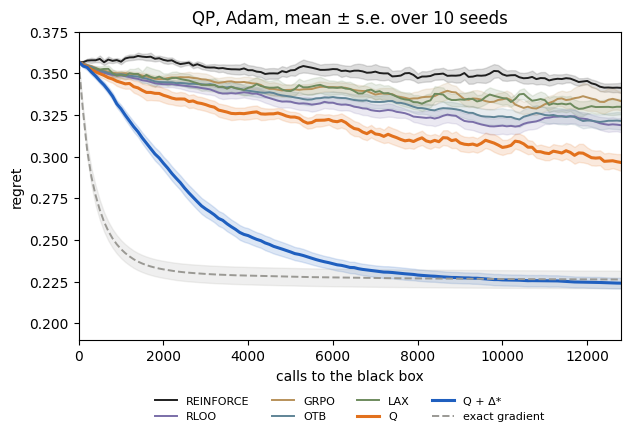

regret           mean over the run   final
REINFORCE                    0.351   0.341
RLOO                         0.332   0.319
GRPO                         0.340   0.333
OTB                          0.335   0.321
LAX                          0.340   0.330
Q                            0.320   0.296
Q + Δ*                       0.253   0.224
exact gradient               0.233   0.226


In [8]:
COL = {"REINFORCE": "#1f1f1f", "RLOO": "#7a6ea8", "GRPO": "#b8925a", "OTB": "#5f8496", "LAX": "#6e8b5e", "RELAX": "#6e8b5e", "V": "#c2648a",
       "Q": "#e2711d", "Q + Δ*": "#1f5fbf", "exact gradient": "#9a9994"}                  # the paper's colors
runs = {n: np.stack([np.load(path(n, s)) for s in SEEDS]) for n in METHODS}
x = np.arange(0, CALLS + 1, 100)
fig, ax = plt.subplots(figsize=(7, 4))
for n, L in runs.items():
    m, se = L.mean(0), L.std(0, ddof=1) / np.sqrt(len(L))
    ls = "--" if n == "exact gradient" else "-"; lw = 2.2 if n.startswith("Q") else 1.4
    ax.plot(x, m, ls=ls, lw=lw, color=COL[n], label=n); ax.fill_between(x, m - se, m + se, color=COL[n], alpha=0.15)
ax.set(xlabel="calls to the black box", ylabel="regret", ylim=(0.19, 0.375), xlim=(0, CALLS),
       title=f"QP, Adam, mean ± s.e. over {len(SEEDS)} seeds")
ax.legend(loc="upper center", bbox_to_anchor=(0.5, -0.15), ncol=4, fontsize=8, frameon=False); plt.show()

print(f"{'regret':16s}{'mean over the run':>18s}{'final':>8s}")
for n, L in runs.items():
    print(f"{n:16s}{L.mean():>18.3f}{L[:, -1].mean():>8.3f}")